Pairs compared: 229

                                      pair  n_taxa_cointegrated  n_taxa_separate  mantel_r_cointegrated  mantel_r_separate  delta_mantel_r
                    Inc11__rep_cluster_556                    5                6               0.999692          -0.253576        1.253267
                  IncFII__rep_cluster_2313                    5                6               0.996476          -0.200887        1.197363
         rep_cluster_1006__rep_cluster_707                    9                8               0.929736          -0.221729        1.151465
        rep_cluster_1110__rep_cluster_1442                    8                4               0.995156          -0.124363        1.119520
                  IncFIB__rep_cluster_1804                    5                6               0.998864          -0.118828        1.117692
                   IncFIB__rep_cluster_312                    6                9               0.895003          -0.138413        1.033416
ColRNA

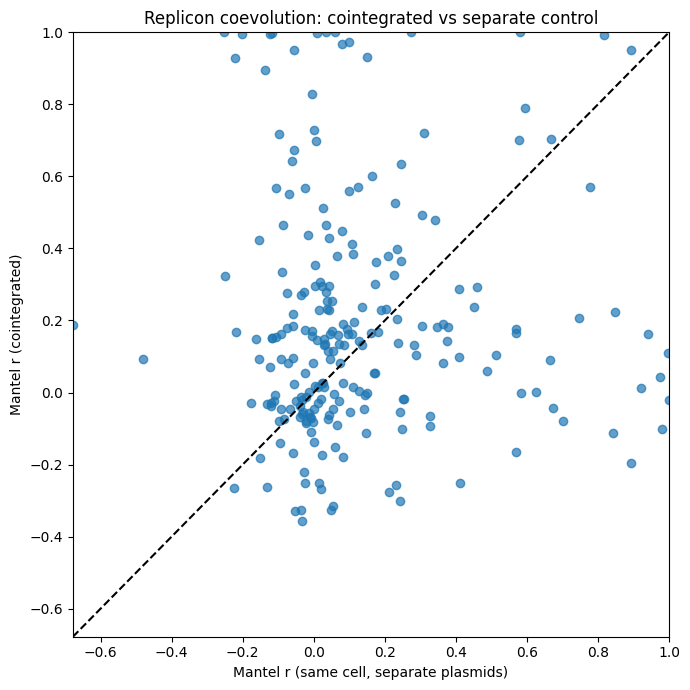

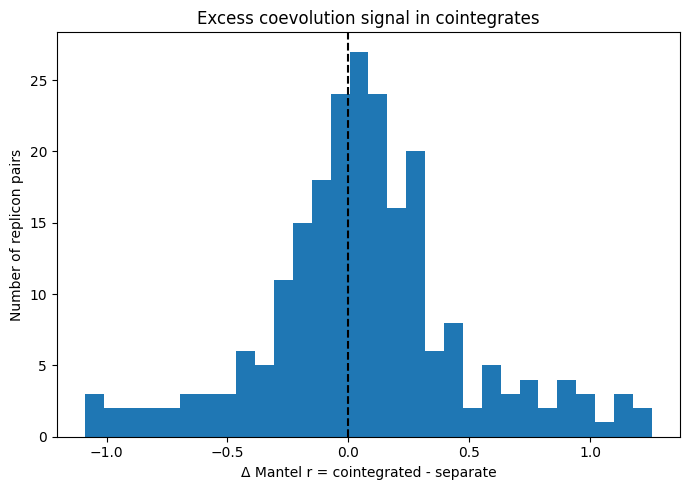

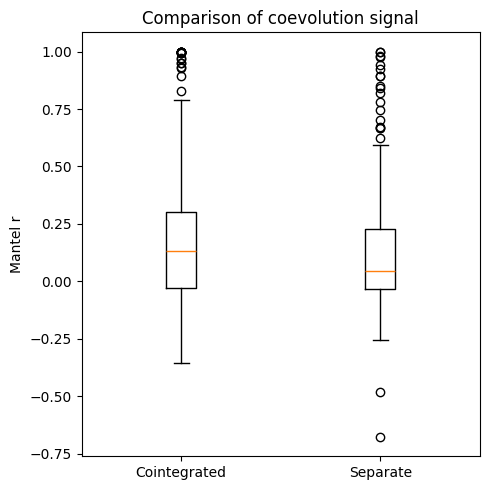

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, spearmanr

# ============================================================
# INPUTS
# ============================================================
ORIG_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/treesreplicons/pairwise_mantel_results.tsv"
CTRL_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/control_fastas/pairwise_mantel_results_control.tsv"

OUT_TABLE = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/mantel_cointegrated_vs_control.tsv"
OUT_SCATTER = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/mantel_cointegrated_vs_control_scatter.png"
OUT_HIST = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/mantel_delta_hist.png"
OUT_BOX = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/mantel_cointegrated_vs_control_boxplot.png"

# ============================================================
# HELPERS
# ============================================================
def clean_rep(x):
    x = str(x).strip()
    x = x.replace("_all_aligned.fasta", "")
    x = x.replace("_aligned.fasta", "")
    x = x.replace(".fasta", "")
    return x

def canon_pair(a, b):
    return "__".join(sorted([str(a), str(b)]))

# ============================================================
# LOAD
# ============================================================
orig = pd.read_csv(ORIG_FILE, sep="\t")
ctrl = pd.read_csv(CTRL_FILE, sep="\t")

# ============================================================
# NORMALIZE ORIGINAL
# ============================================================
orig = orig.copy()
orig["repA"] = orig["repA"].apply(clean_rep)
orig["repB"] = orig["repB"].apply(clean_rep)
orig["pair"] = orig.apply(lambda r: canon_pair(r["repA"], r["repB"]), axis=1)

# ============================================================
# NORMALIZE CONTROL
# ============================================================
ctrl = ctrl.copy()
ctrl["repA"] = ctrl["repA"].apply(clean_rep)
ctrl["repB"] = ctrl["repB"].apply(clean_rep)
ctrl["pair"] = ctrl.apply(lambda r: canon_pair(r["repA"], r["repB"]), axis=1)

# ============================================================
# MERGE
# ============================================================
merged = orig.merge(
    ctrl[["pair", "n_taxa", "mantel_r", "mantel_p", "mirror_r", "mirror_p_emp"]],
    on="pair",
    how="inner",
    suffixes=("_cointegrated", "_separate")
)

merged["delta_mantel_r"] = merged["mantel_r_cointegrated"] - merged["mantel_r_separate"]
merged["delta_mirror_r"] = merged["mirror_r_cointegrated"] - merged["mirror_r_separate"]

merged = merged.sort_values("delta_mantel_r", ascending=False).reset_index(drop=True)
merged.to_csv(OUT_TABLE, sep="\t", index=False)

print("Pairs compared:", len(merged))
print()
print(merged[[
    "pair",
    "n_taxa_cointegrated", "n_taxa_separate",
    "mantel_r_cointegrated", "mantel_r_separate",
    "delta_mantel_r"
]].head(20).to_string(index=False))

# ============================================================
# BASIC STATS
# ============================================================
x = merged["mantel_r_cointegrated"].values
y = merged["mantel_r_separate"].values
delta = merged["delta_mantel_r"].values

print("\nSummary:")
print(f"Mean Mantel r (cointegrated): {np.mean(x):.4f}")
print(f"Mean Mantel r (separate):     {np.mean(y):.4f}")
print(f"Mean delta:                   {np.mean(delta):.4f}")
print(f"Median delta:                 {np.median(delta):.4f}")
print(f"Fraction delta > 0:           {(delta > 0).mean():.4f}")

# paired Wilcoxon
try:
    w = wilcoxon(x, y, alternative="greater")
    print(f"\nWilcoxon paired test (cointegrated > separate): W={w.statistic}, p={w.pvalue:.4e}")
except Exception as e:
    print("\nWilcoxon test failed:", e)

# correlation between both effects
rho, p_rho = spearmanr(x, y)
print(f"Spearman correlation between cointegrated and separate Mantel r: rho={rho:.4f}, p={p_rho:.4e}")

# ============================================================
# SCATTER
# ============================================================
plt.figure(figsize=(7, 7))
plt.scatter(
    merged["mantel_r_separate"],
    merged["mantel_r_cointegrated"],
    alpha=0.7
)
lims = [
    min(merged["mantel_r_separate"].min(), merged["mantel_r_cointegrated"].min()),
    max(merged["mantel_r_separate"].max(), merged["mantel_r_cointegrated"].max())
]
plt.plot(lims, lims, linestyle="--", color="black")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Mantel r (same cell, separate plasmids)")
plt.ylabel("Mantel r (cointegrated)")
plt.title("Replicon coevolution: cointegrated vs separate control")
plt.tight_layout()
plt.savefig(OUT_SCATTER, dpi=300)
plt.show()

# ============================================================
# HISTOGRAM OF DELTA
# ============================================================
plt.figure(figsize=(7, 5))
plt.hist(merged["delta_mantel_r"], bins=30)
plt.axvline(0, linestyle="--", color="black")
plt.xlabel("Δ Mantel r = cointegrated - separate")
plt.ylabel("Number of replicon pairs")
plt.title("Excess coevolution signal in cointegrates")
plt.tight_layout()
plt.savefig(OUT_HIST, dpi=300)
plt.show()

# ============================================================
# BOXPLOT
# ============================================================
plt.figure(figsize=(5, 5))
plt.boxplot(
    [merged["mantel_r_cointegrated"], merged["mantel_r_separate"]],
    labels=["Cointegrated", "Separate"]
)
plt.ylabel("Mantel r")
plt.title("Comparison of coevolution signal")
plt.tight_layout()
plt.savefig(OUT_BOX, dpi=300)
plt.show()

ALL
N cointegrated: 314
N control: 236

SIGNIFICANT ONLY
N cointegrated: 100
N control: 73


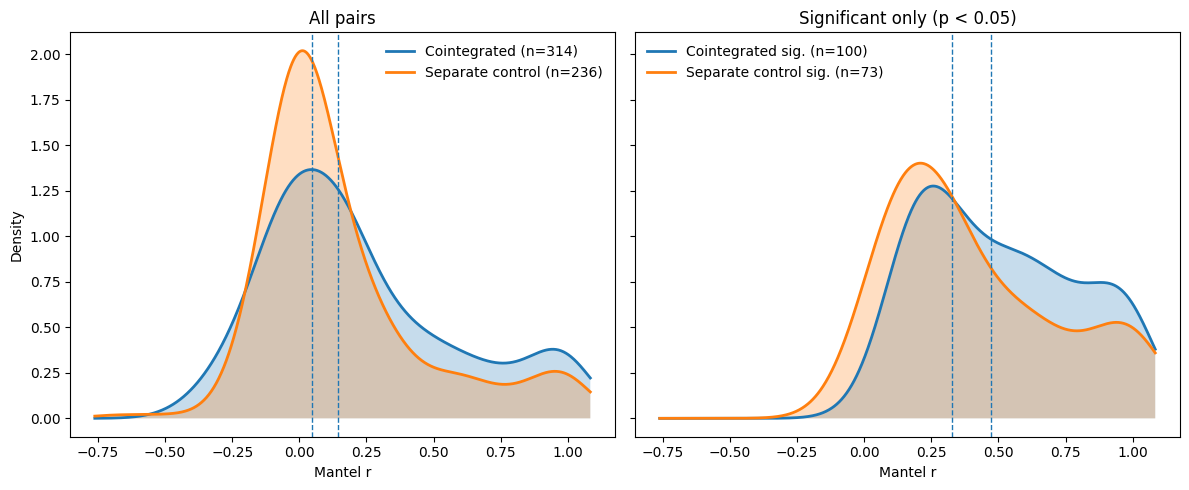

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ============================================================
# INPUTS
# ============================================================
ORIG_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/treesreplicons/pairwise_mantel_results.tsv"
CTRL_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/control_fastas/pairwise_mantel_results_control.tsv"

OUT_PNG = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/kde_mantel_vs_control_two_panels.png"
OUT_SVG = "/home/nacho/HDD16/Nacho/RepliCOOC/rep_distances/letsshowmultirepps/control_mantel/kde_mantel_vs_control_two_panels.svg"

PV_CUTOFF = 0.05

# ============================================================
# LOAD
# ============================================================
orig = pd.read_csv(ORIG_FILE, sep="\t")
ctrl = pd.read_csv(CTRL_FILE, sep="\t")

orig["mantel_p"] = pd.to_numeric(orig["mantel_p"], errors="coerce")
ctrl["mantel_p"] = pd.to_numeric(ctrl["mantel_p"], errors="coerce")
orig["mantel_r"] = pd.to_numeric(orig["mantel_r"], errors="coerce")
ctrl["mantel_r"] = pd.to_numeric(ctrl["mantel_r"], errors="coerce")

# all values
x1_all = orig["mantel_r"].dropna().values
x2_all = ctrl["mantel_r"].dropna().values

# significant only
x1_sig = orig.loc[orig["mantel_p"] < PV_CUTOFF, "mantel_r"].dropna().values
x2_sig = ctrl.loc[ctrl["mantel_p"] < PV_CUTOFF, "mantel_r"].dropna().values

print("ALL")
print("N cointegrated:", len(x1_all))
print("N control:", len(x2_all))
print()
print("SIGNIFICANT ONLY")
print("N cointegrated:", len(x1_sig))
print("N control:", len(x2_sig))

# ============================================================
# COMMON X RANGE
# ============================================================
all_vals = np.concatenate([x1_all, x2_all, x1_sig, x2_sig])
xmin = all_vals.min()
xmax = all_vals.max()
pad = 0.05 * (xmax - xmin if xmax > xmin else 1)
grid = np.linspace(xmin - pad, xmax + pad, 1000)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# ---------- panel 1: all pairs ----------
kde1_all = gaussian_kde(x1_all)
kde2_all = gaussian_kde(x2_all)
y1_all = kde1_all(grid)
y2_all = kde2_all(grid)

axes[0].plot(grid, y1_all, linewidth=2, label=f"Cointegrated (n={len(x1_all)})")
axes[0].fill_between(grid, 0, y1_all, alpha=0.25)

axes[0].plot(grid, y2_all, linewidth=2, label=f"Separate control (n={len(x2_all)})")
axes[0].fill_between(grid, 0, y2_all, alpha=0.25)

axes[0].axvline(np.median(x1_all), linestyle="--", linewidth=1)
axes[0].axvline(np.median(x2_all), linestyle="--", linewidth=1)

axes[0].set_title("All pairs")
axes[0].set_xlabel("Mantel r")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)

# ---------- panel 2: significant only ----------
kde1_sig = gaussian_kde(x1_sig)
kde2_sig = gaussian_kde(x2_sig)
y1_sig = kde1_sig(grid)
y2_sig = kde2_sig(grid)

axes[1].plot(grid, y1_sig, linewidth=2, label=f"Cointegrated sig. (n={len(x1_sig)})")
axes[1].fill_between(grid, 0, y1_sig, alpha=0.25)

axes[1].plot(grid, y2_sig, linewidth=2, label=f"Separate control sig. (n={len(x2_sig)})")
axes[1].fill_between(grid, 0, y2_sig, alpha=0.25)

axes[1].axvline(np.median(x1_sig), linestyle="--", linewidth=1)
axes[1].axvline(np.median(x2_sig), linestyle="--", linewidth=1)

axes[1].set_title(f"Significant only (p < {PV_CUTOFF})")
axes[1].set_xlabel("Mantel r")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300)
plt.savefig(OUT_SVG)
plt.show()